# Data Preprocessing CLV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/Online Retail.csv", encoding="ISO-8859-1")

In [3]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Handling Null Values

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

 **We can't assume the CustomerID. So, removing is only option.**

In [5]:
df = df.dropna(subset=["CustomerID"])

### Handling Duplicate Value

In [6]:
df.duplicated().sum()

np.int64(5225)

In [7]:
df = df.drop_duplicates()

### Handing Non Positive Numbers

**Cancelled product are consider as negative values**

In [8]:
neg_df = df[df['Quantity'] <0]

In [9]:
neg_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,01-12-2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01-12-2010 09:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,01-12-2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom


In [10]:
df = df[df["Quantity"] > 0]

**Free Product Has no effect.So, remove those.**

In [11]:
df = df[df["UnitPrice"] > 0]

### Total Revenue for Calculating CLV

In [12]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

**CustomerID is in Obj, need to be in Numeric**

In [13]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [14]:
df.describe()

,Quantity,UnitPrice,CustomerID,Revenue
count,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,15287.843865,22.631500
std,180.492832,22.241836,1713.539549,311.099224
min,1.000000,0.001000,12346.000000,0.001000
25%,2.000000,1.250000,13955.000000,4.950000
50%,6.000000,1.950000,15150.000000,12.450000
75%,12.000000,3.750000,16791.000000,19.800000
max,80995.000000,8142.750000,18287.000000,168469.600000


In [15]:
df.shape

(392692, 9)

#### InvoiceDate (dd/mm/yyyy/hh/MM) to (yyyy/mm/dd/hh/MM)

In [16]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],dayfirst = True)

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Check StockCode for Non-Real product.

In [18]:
df[~df["StockCode"].str.isnumeric()]["StockCode"].unique()

array(['85123A', '84406B', '84029G', '84029E', 'POST', '82494L', '85099C',
       '84997B', '84997C', '84519A', '85183B', '85071B', '37444A',
       '37444C', '84971S', '15056BL', '15056N', '85049A', '85099B',
       '35004C', '35004G', '85014B', '85014A', '84970S', '84030E',
       '35004B', '85049E', '17091A', '84509A', '84510A', '84709B',
       '84625C', '84625A', '47570B', '85049C', '85049D', '85049G',
       '84970L', '90199C', '90129F', '90210B', '72802C', '85169B',
       '85099F', '85184C', '35591T', '84032B', '85049H', '72800E',
       '84849B', '90200B', '90059B', '90185C', '90059E', '90059C',
       '90200C', '90200D', '90200A', '16258A', '85231B', '85231G',
       '48173C', '47563A', '84558A', '46000M', '71406C', '84985A',
       '84596E', '84997D', '47599A', '47599B', '85035B', '84968C',
       '72800B', '84563A', '47504H', '17164B', '15044B', '84569B',
       '85114B', '85114C', '85199L', '85199S', '85019A', '85019C',
       '85071A', '85071C', '85135B', '85136A', '85136

In [19]:
remove_codes = ["POST", "M", "C2", "DOT", "PADS", "BANK CHARGES"]

df = df[~df["StockCode"].isin(remove_codes)]

### Checking for outliers

**Quantity Outliers**

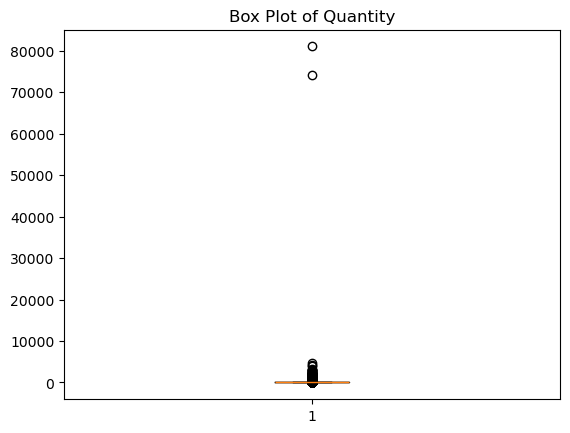

In [20]:
plt.figure()
plt.boxplot(df["Quantity"])
plt.title("Box Plot of Quantity")
plt.show()

In [21]:
ls1=[]
top_10 = df['Quantity'].nlargest(n=10)
for i in top_10:
    ls1.append(i)

In [22]:
high_quantity = df[df['Quantity'].isin(ls1)]
high_quantity.sort_values('Quantity',ascending = False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.60
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901,United Kingdom,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135,United Kingdom,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087,United Kingdom,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609,United Kingdom,191.16
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749,United Kingdom,6539.40
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308,United Kingdom,960.00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,16754,United Kingdom,518.40


**UnitPrice Outlier**

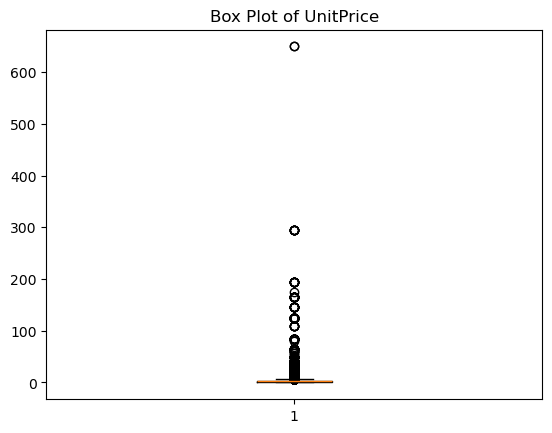

In [23]:
plt.figure()
plt.boxplot(df["UnitPrice"])
plt.title("Box Plot of UnitPrice")
plt.show()

In [24]:
ls2=[]
top_10 = df['UnitPrice'].nlargest(n=10)
for i in top_10:
    ls2.append(i)

In [25]:
high_unitprice = df[df['UnitPrice'].isin(ls2)]
high_unitprice.sort_values('UnitPrice',ascending = False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.5,15098,United Kingdom,38970.0
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.5,15098,United Kingdom,649.5
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02 18:06:00,295.0,13145,United Kingdom,295.0
32484,539080,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-16 08:41:00,295.0,16607,United Kingdom,295.0
51636,540647,22655,VINTAGE RED KITCHEN CABINET,1,2011-01-10 14:57:00,295.0,17406,United Kingdom,295.0
82768,543253,22655,VINTAGE RED KITCHEN CABINET,1,2011-02-04 15:32:00,295.0,14842,United Kingdom,295.0
118769,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-14 11:38:00,295.0,13452,United Kingdom,295.0
133994,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-25 14:19:00,295.0,13452,United Kingdom,295.0
171178,551393,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-04-28 12:22:00,295.0,14973,United Kingdom,295.0
205759,554836,22655,VINTAGE RED KITCHEN CABINET,1,2011-05-26 16:25:00,295.0,13015,United Kingdom,295.0


**Revenue Outliers**

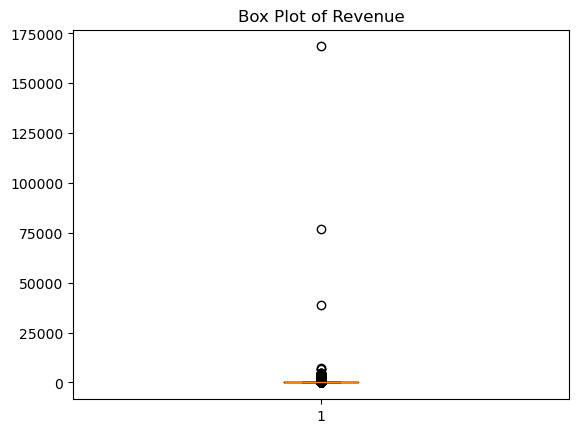

In [26]:
plt.figure()
plt.boxplot(df["Revenue"])
plt.title("Box Plot of Revenue")
plt.show()

In [27]:
ls3=[]
top_10 = df['Revenue'].nlargest(n=10)
for i in top_10:
    ls3.append(i)

In [28]:
high_unitprice = df[df['Revenue'].isin(ls3)]
high_unitprice.sort_values('Revenue',ascending = False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098,United Kingdom,38970.00
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450,United Kingdom,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646,Netherlands,4992.00
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-01-11 12:55:00,2.55,15749,United Kingdom,4921.50
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-04-18 13:20:00,2.40,15749,United Kingdom,4632.00
52772,540818,48185,DOORMAT FAIRY CAKE,670,2011-01-11 12:57:00,6.75,15749,United Kingdom,4522.50


### Check top 3 customer in top 10 revenue customer

In [29]:
df[df["CustomerID"] == 16446]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446,United Kingdom,1.65
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446,United Kingdom,1.25
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60


In [30]:
df[df["CustomerID"] == 12346]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.6


In [31]:
df[df["CustomerID"] == 15098]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
222670,556442,22502,PICNIC BASKET WICKER SMALL,60,2011-06-10 15:22:00,4.95,15098,United Kingdom,297.0
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098,United Kingdom,38970.0
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.50,15098,United Kingdom,649.5


**From Quantity, UnitPrice, Revenue removing outliers**

In [32]:
Outliers = [168469.60,77183.6]
df = df[~df['Revenue'].isin(Outliers)]

***Since those are Non regular Purchase***

### EDA

In [33]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 391148 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    391148 non-null  object        
 1   StockCode    391148 non-null  object        
 2   Description  391148 non-null  object        
 3   Quantity     391148 non-null  int64         
 4   InvoiceDate  391148 non-null  datetime64[ns]
 5   UnitPrice    391148 non-null  float64       
 6   CustomerID   391148 non-null  int64         
 7   Country      391148 non-null  object        
 8   Revenue      391148 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 29.8+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,391148.000000,391148,391148.000000,391148.000000,391148.000000
mean,12.748561,2011-07-10 19:37:39.589311488,2.874379,15295.176054,21.709364
min,1.000000,2010-12-01 08:26:00,0.040000,12347.000000,0.060000
25%,2.000000,2011-04-07 11:16:00,1.250000,13969.000000,4.950000
50%,6.000000,2011-07-31 12:05:00,1.950000,15159.000000,11.900000
75%,12.000000,2011-10-20 12:57:00,3.750000,16794.000000,19.800000
max,4800.000000,2011-12-09 12:50:00,649.500000,18287.000000,38970.000000
std,42.999050,NaN,4.284748,1710.335915,94.423572


**Top 10 Product with high revenue**

In [34]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
RABBIT NIGHT LIGHT                     51251.24
CHILLI LIGHTS                          46265.11
PAPER CHAIN KIT 50'S CHRISTMAS         42584.13
PICNIC BASKET WICKER 60 PIECES         39619.50
BLACK RECORD COVER FRAME               39045.80
Name: Revenue, dtype: float64

**Top 10 CustomerID with high revenue**

In [35]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
14646    279138.02
18102    259657.30
17450    194390.79
14911    136161.83
12415    124564.53
14156    116560.08
17511     91062.38
16029     72708.09
16684     66653.56
13694     65039.62
Name: Revenue, dtype: float64

**Top 10 Country with high revenue**

In [36]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_revenue


Country
United Kingdom          6997202.12
Netherlands              283889.34
EIRE                     257013.12
Germany                  205381.15
France                   183801.94
Australia                138103.81
Spain                     55706.56
Switzerland               52441.95
Japan                     37416.37
Belgium                   36927.34
Sweden                    36828.83
Norway                    32454.64
Portugal                  26643.90
Channel Islands           19997.54
Finland                   18344.88
Denmark                   18211.34
Italy                     15820.24
Cyprus                    13167.16
Singapore                  9120.39
Austria                    8742.68
Israel                     7215.84
Poland                     6974.65
Greece                     4425.52
Iceland                    4310.00
USA                        3580.39
Canada                     3115.44
Unspecified                2660.77
Malta                      2070.59
United Arab 

<Axes: xlabel='YearMonth'>

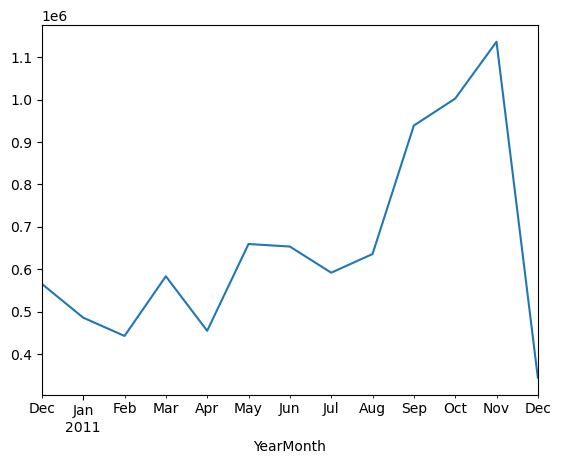

In [37]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("YearMonth")["Revenue"].sum()

monthly_revenue.plot()

In [39]:
df.to_csv("../data/processed_online_retail.csv", index=False)

## END of the Code